# Computing Tempered Energy 

We aim to implement a parallel tempering scheme for annealed MCMC as per Du et al.'s [2024 paper](https://arxiv.org/pdf/2302.11552) on compositional generation with energy-based diffusion. In order to implement parallel tempering into the sampling regime of annealed MCMC, we aim to evaluate the difference between true tempered energy and our approximations.

Training follows standard DDPM noise-matching objective

### Setup

In [1]:
from src.eval import ladder_ddpm, plot_acceptance_over_time, plot_acceptance_over_position

### Sample

Note that function `plot_samples_grid` will take in a list of methods and dataset names and plot them in a grid. Function `samples_tuning` will take in a single method (ULA or MALA) and dataset name, as well as a list `step_scales_list` and `n_langevin_steps_list` and output a grid of samples for each hyperparameter. 

Running with 10 steps for [6. 5. 4. 3. 2. 1.]
  t        :     9  |     8  |     7  |     6  |     5  |     4  |     3  |     2  |     1  |     0  | 
  Chain 6.0: 30.50 -> 26.47 -> 22.55 -> 19.27 -> 16.39 -> 13.73 -> 11.23 ->  8.83 ->  6.66 ->  5.26 -> 
  Swap   ^ :               0.89              0.68              0.58              0.49              0.49
  Chain 5.0: 30.50 -> 26.47 -> 22.56 -> 19.31 -> 16.42 -> 13.81 -> 11.31 ->  8.98 ->  6.84 ->  5.50 -> 
  Swap   ^ :      1.00              0.68              0.50              0.41              0.35         
  Chain 4.0: 30.50 -> 26.48 -> 22.60 -> 19.35 -> 16.53 -> 13.92 -> 11.50 ->  9.20 ->  7.16 ->  5.82 -> 
  Swap   ^ :               0.80              0.48              0.35              0.27              0.21
  Chain 3.0: 30.50 -> 26.50 -> 22.64 -> 19.45 -> 16.65 -> 14.14 -> 11.76 ->  9.59 ->  7.63 ->  6.39 -> 
  Swap   ^ :      1.00              0.46              0.29              0.20              0.14         
  Chain 2.0: 30.50

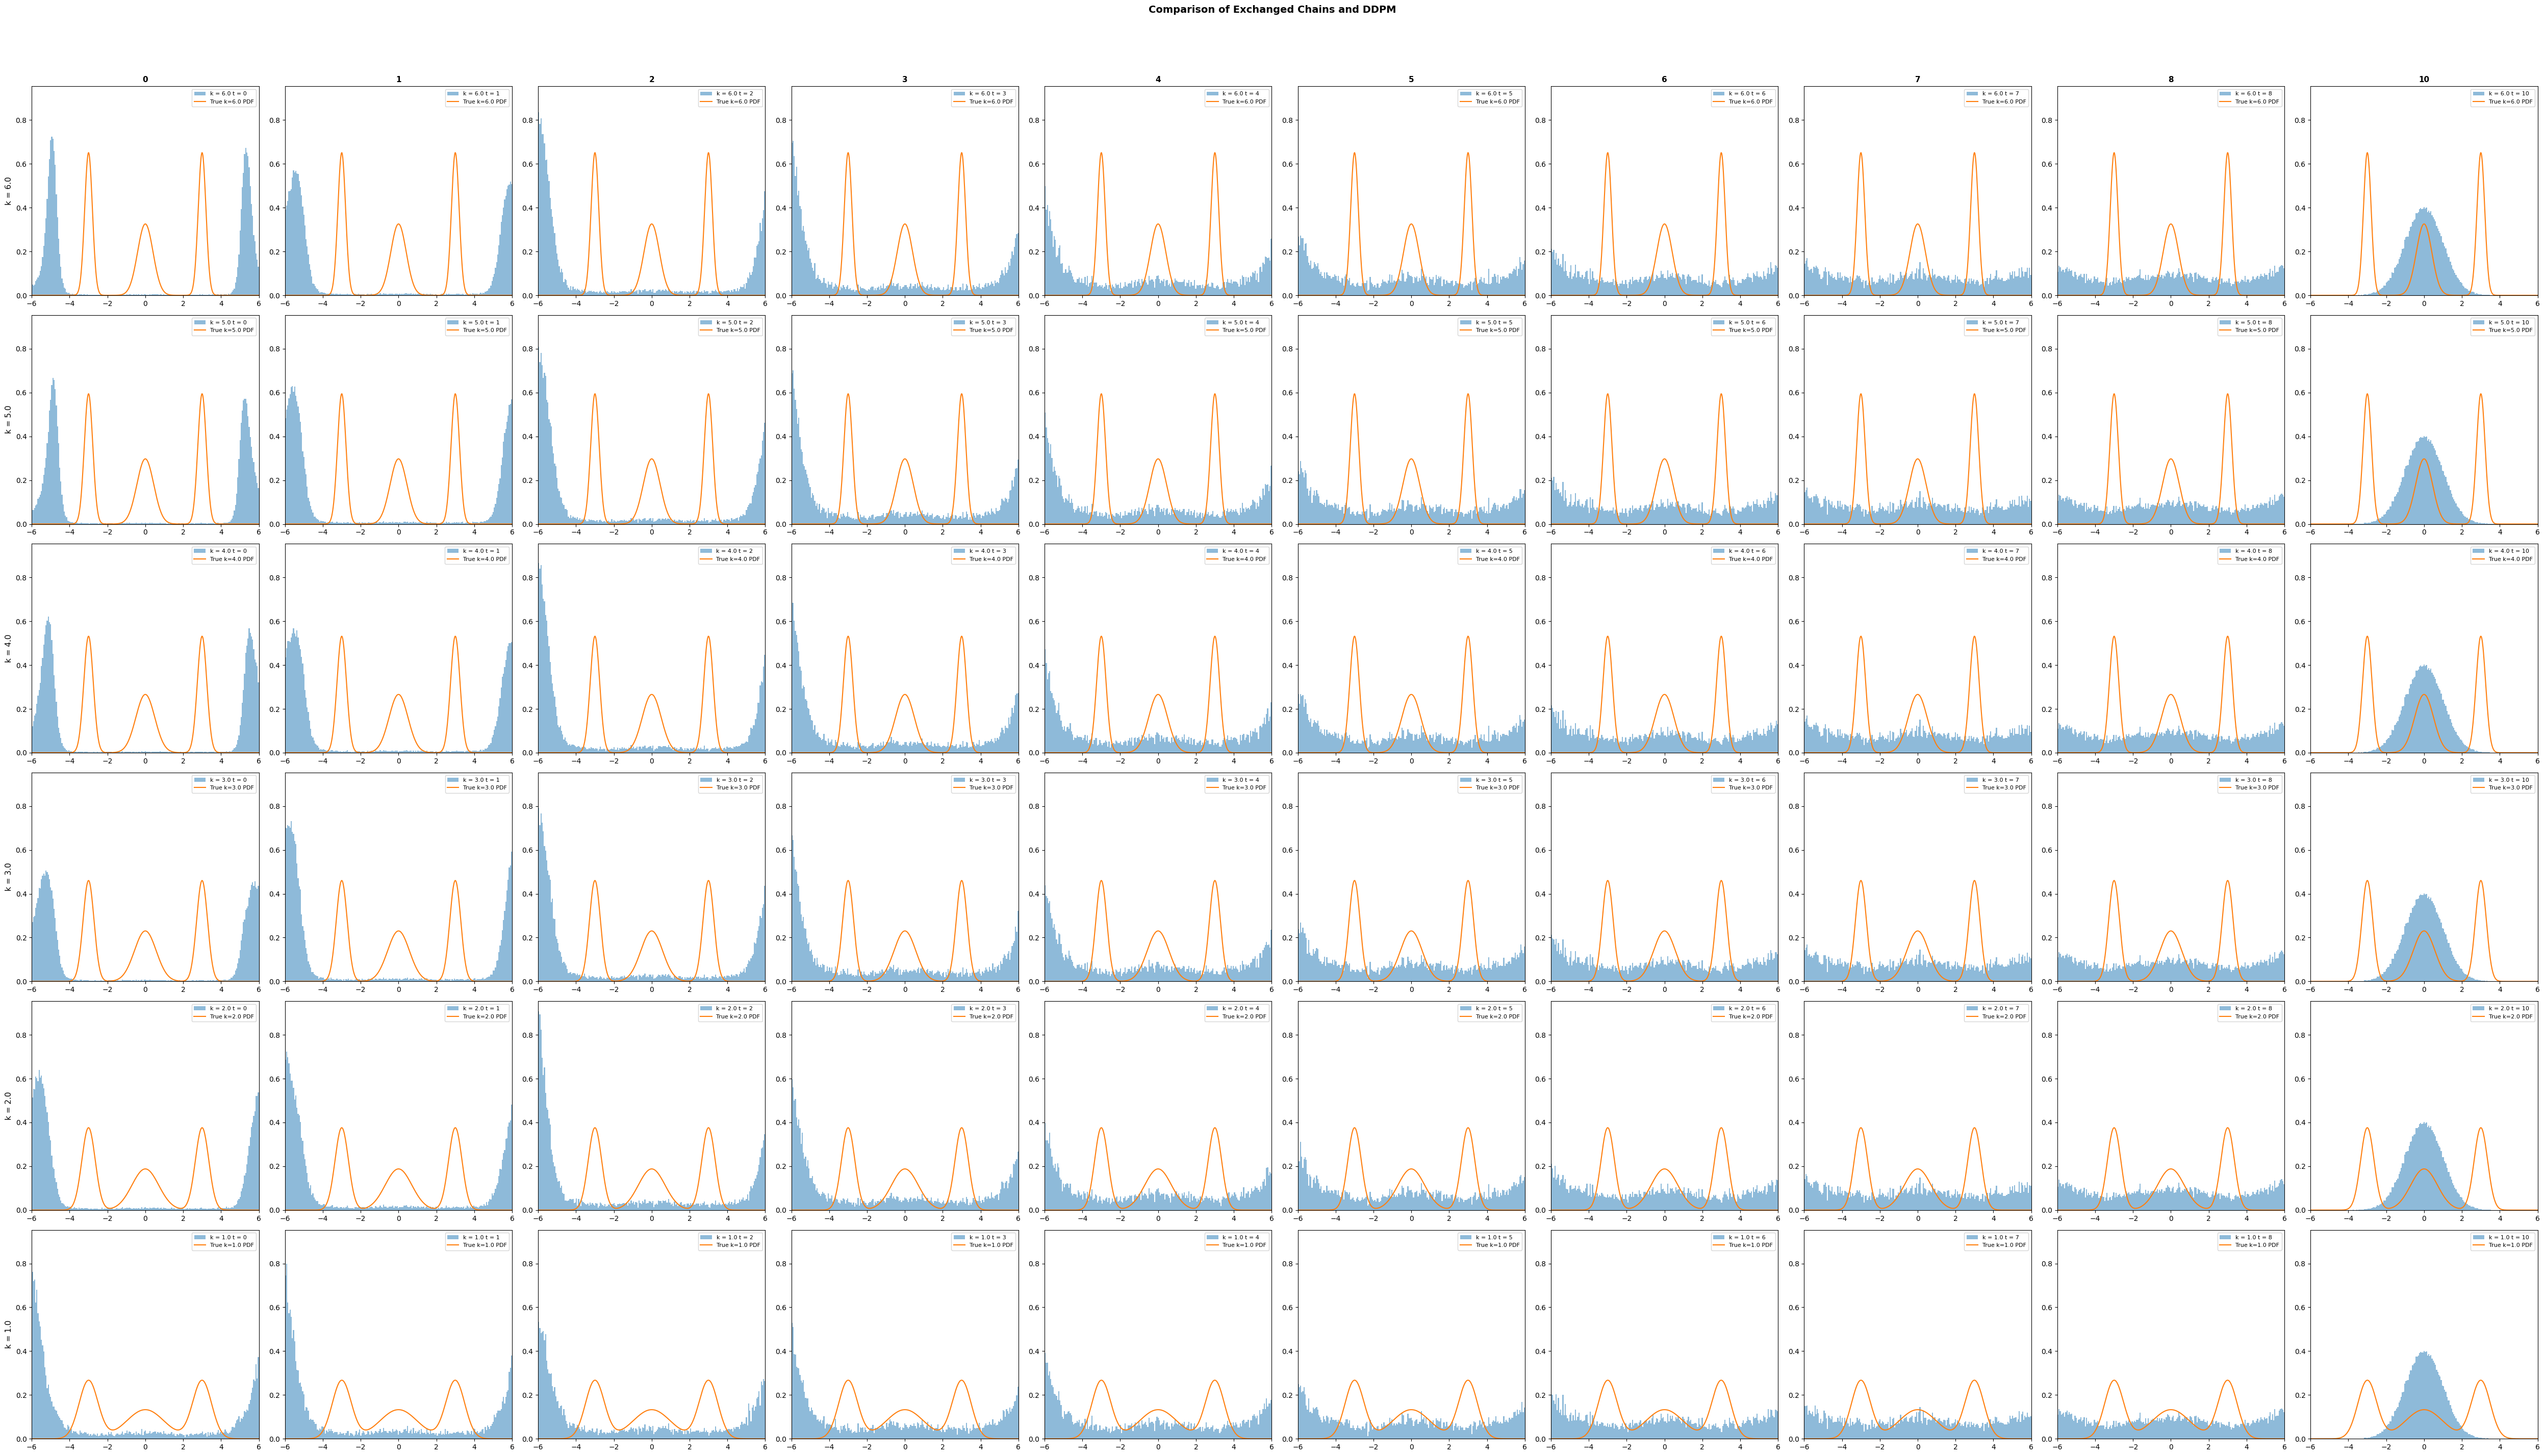

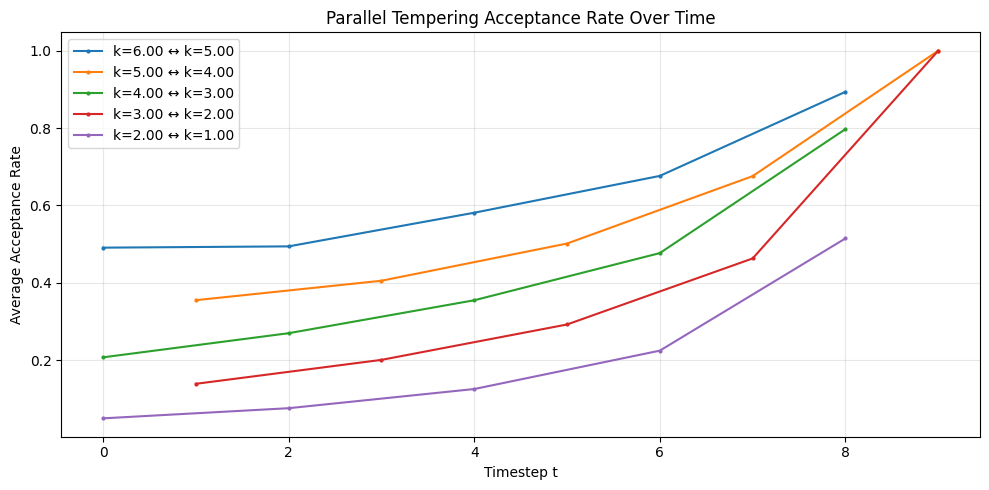

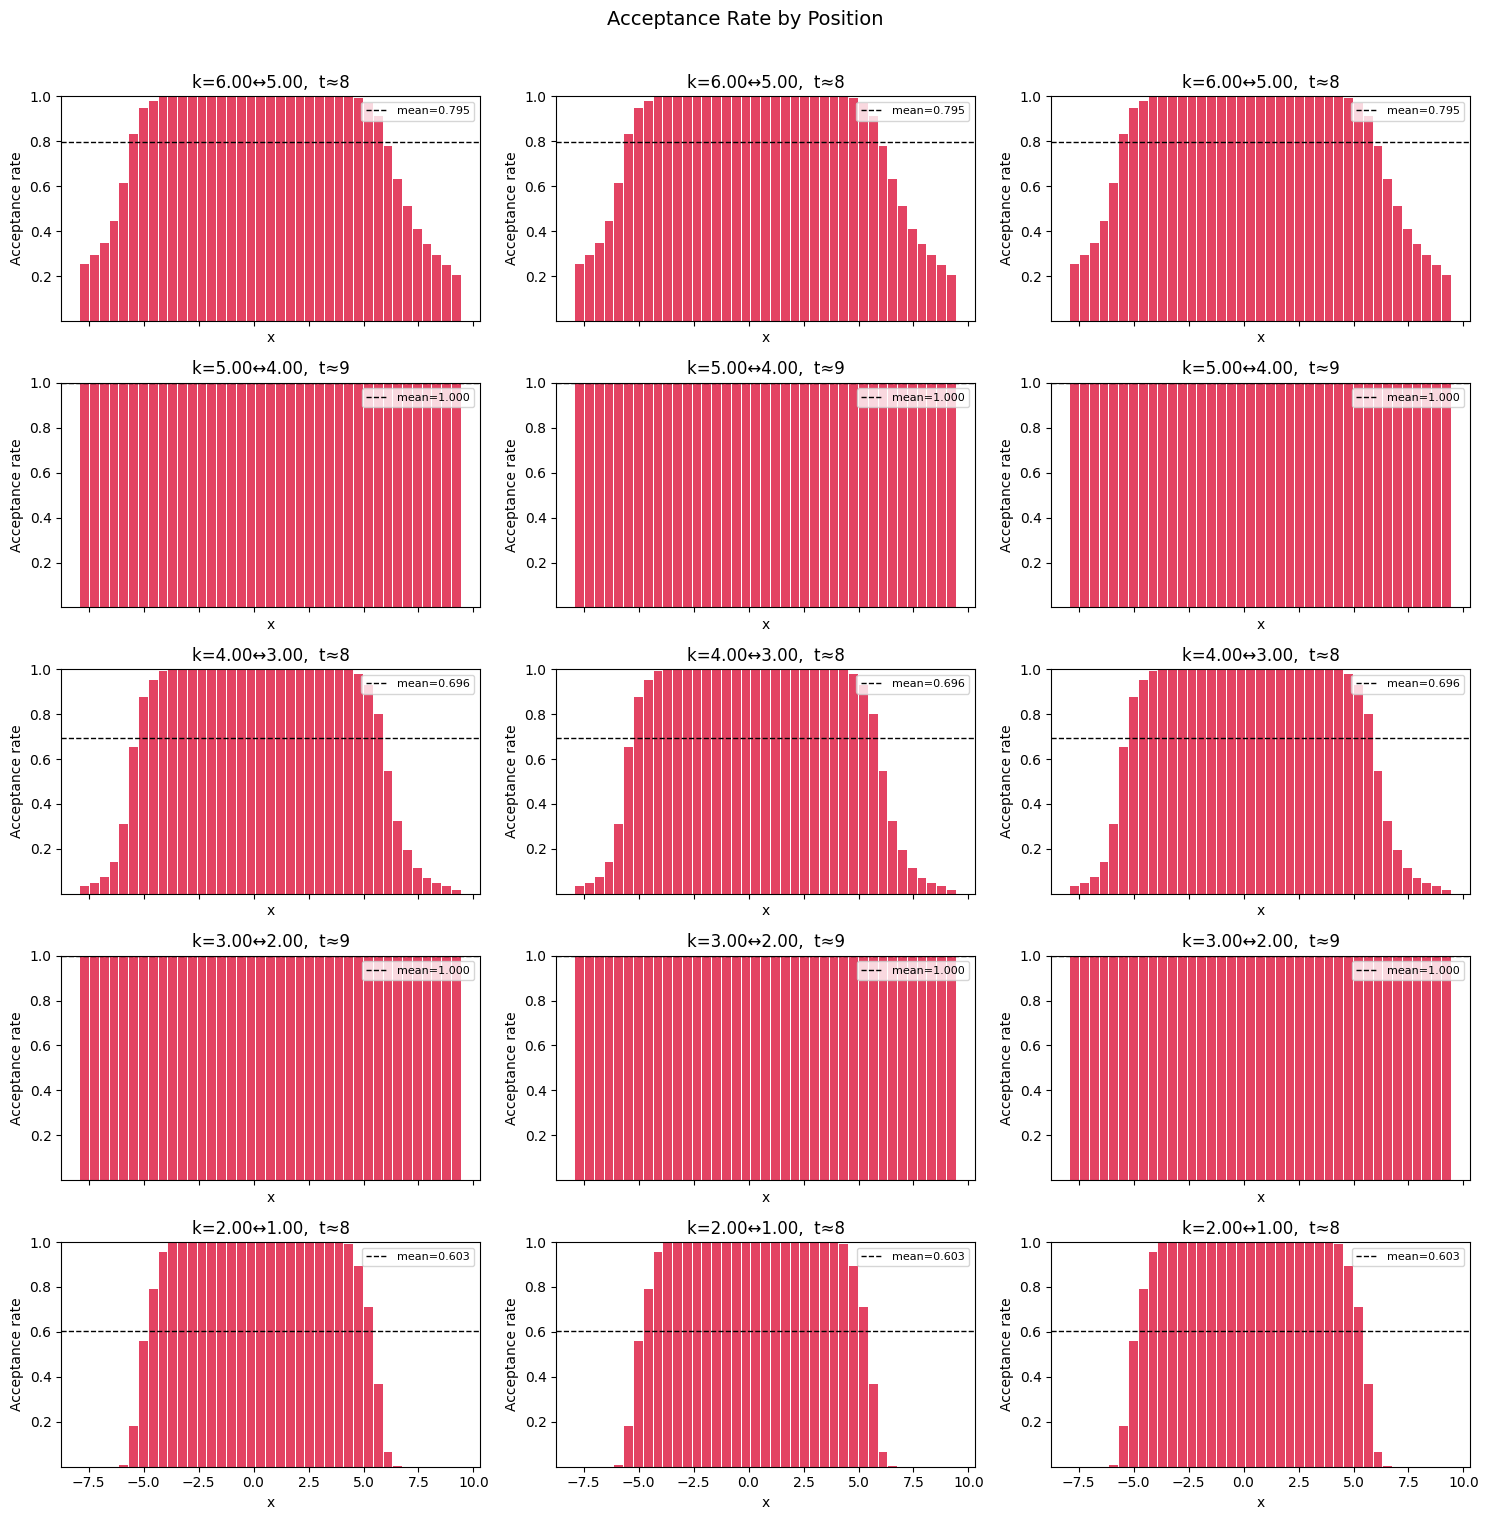

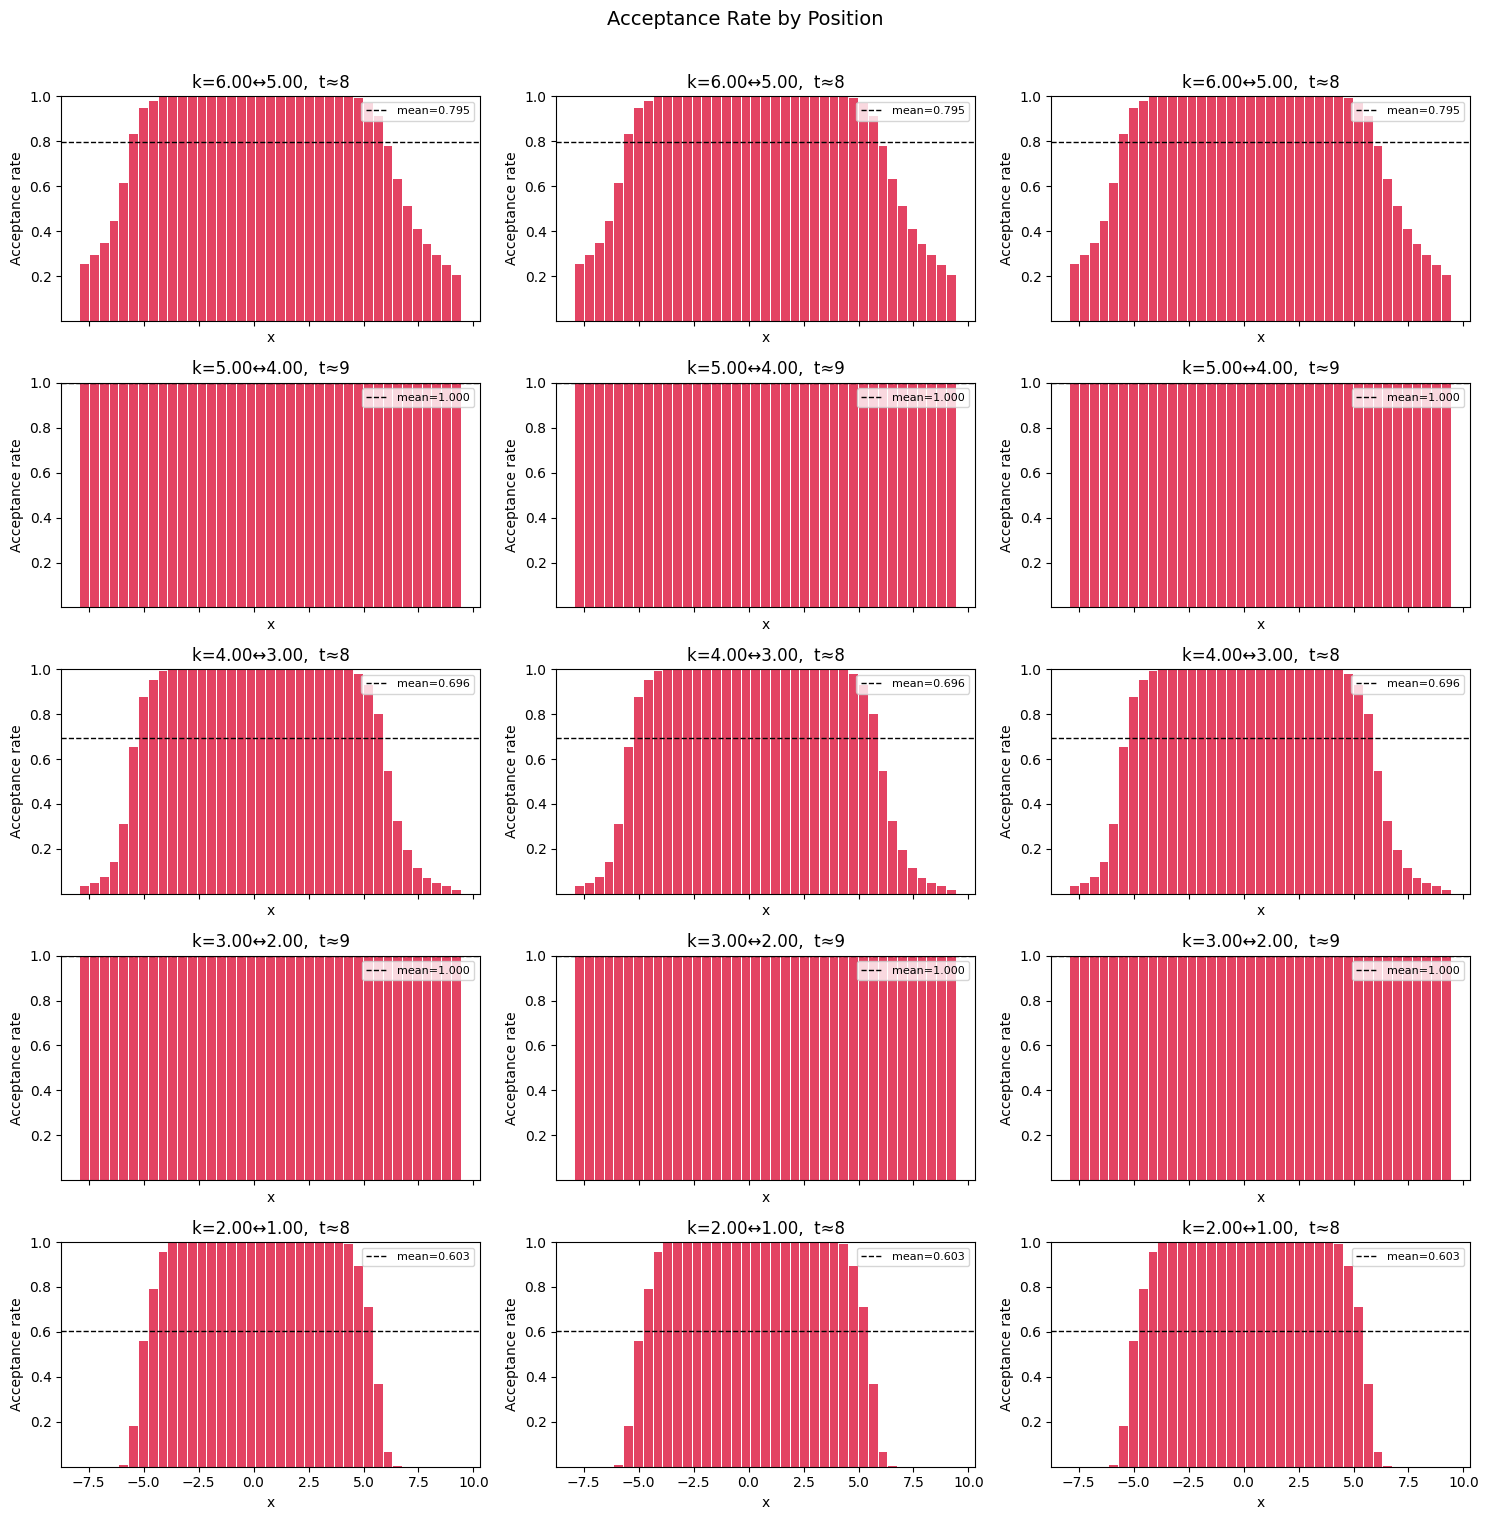

In [ ]:
dataset_name = "composed"
k = 6.0
sigma = 0.5
step_scale = 1
n_langevin_steps = 3
n_replicas = 6

x_ladder, a_ladder = ladder_ddpm(dataset_name, k, sigma, step_scale, n_langevin_steps, n_replicas, x_limit=6, save_dir="figures", figsize_per_panel=(5,4), filename=None)
plot_acceptance_over_time(a_ladder)
_ = plot_acceptance_over_position(a_ladder, x_ladder[0][k])